In [1]:
context_size = 10
batch_size = 128
import re

def clean_text(text, pattern = r'[^a-zA-Z0-9 \.\n]'):
  text = text.lower()
  text = text.replace("<bos>", "BOSTOKEN")
  text = re.sub(pattern, '', text)
  text = text.replace("BOSTOKEN", "<bos>")
  return text

class Tokenizer:

  def __init__(self, vocab_size = 1e6, pattern = r'[^a-zA-Z0-9 \.\n]') -> None:
    self.vocab_size = vocab_size
    self.pattern = pattern
    self.word_to_idx = {}
    self.idx_to_word = {}
    self.word_freq = {}

  def build_vocab(self, text):
    text = clean_text(text, self.pattern)
    text = text.lower()
    words = re.findall(r'\w+|\n|\.', text)
    unique_words = list(set(words))

    for idx, word in enumerate(unique_words):
      self.word_freq[word] = words.count(word)

    sorted_words = sorted(self.word_freq.items(), key=lambda x: x[1], reverse=True)
    top_words = sorted_words[:int(self.vocab_size)]

    for idx, (word, _) in enumerate(top_words):

      self.word_to_idx[word] = idx
      self.idx_to_word[idx] = word

    self.word_to_idx['<UNK>'] = len(self.word_to_idx)
    self.idx_to_word[len(self.idx_to_word)] = '<UNK>'

  def encode(self, text):
    text = clean_text(text, self.pattern)
    words = re.findall(r'<bos>|\w+|\n|\.', text)
    encoded_text = []
    for word in words:
      if word in self.word_to_idx:
        encoded_text.append(self.word_to_idx[word])
      else:
        encoded_text.append(self.word_to_idx['<UNK>'])
    return encoded_text

  def decode(self, idxs):
    words = []
    for idx in idxs:
      if idx in self.idx_to_word:
        words.append(self.idx_to_word[idx])
      else:
        words.append('<UNK>')

    return ' '.join(words)

In [2]:
with open("warpeace_input.txt", "r", encoding="utf-8-sig") as f:
    corpus = f.read()

corpus = corpus.replace("\n\n", "\n\n" + "<bos>" * context_size)


In [5]:
import pickle
# tokenizer = Tokenizer()
# tokenizer.build_vocab(corpus)

# tokenizer.word_to_idx["<bos>"] = len(tokenizer.word_to_idx)
# tokenizer.idx_to_word[len(tokenizer.idx_to_word)] = "<bos>"


# with open("outputs/war-peace-tokenizer.pkl", "wb") as f:
#     pickle.dump(tokenizer, f)

tokenizer = pickle.load(open("outputs_with dropout/war-peace-tokenizer.pkl", "rb"))


In [6]:
def make_X_y_pairs(corpus, bos_token = "<bos>", context_size = context_size):
  ## text is a list of sentences
  X = []
  y = []
  corpus = context_size * bos_token + corpus
  encoded_text = tokenizer.encode(corpus)
  for i in range(context_size, len(encoded_text)):
    context = encoded_text[i-context_size:i]
    target = encoded_text[i]
    if([target] == tokenizer.encode("<bos>")):
        continue
    X.append(context)
    y.append(target)
  return X, y

In [7]:
X, y = make_X_y_pairs(corpus)
for i in range(400,450):
  print(repr(tokenizer.decode(X[i])), "----->",repr(tokenizer.decode([y[i]])))

'friends mind \n at rest said he without altering his' -----> 'tone'
'mind \n at rest said he without altering his tone' -----> 'beneath'
'\n at rest said he without altering his tone beneath' -----> 'the'
'at rest said he without altering his tone beneath the' -----> 'politeness'
'rest said he without altering his tone beneath the politeness' -----> 'and'
'said he without altering his tone beneath the politeness and' -----> '\n'
'he without altering his tone beneath the politeness and \n' -----> 'affected'
'without altering his tone beneath the politeness and \n affected' -----> 'sympathy'
'altering his tone beneath the politeness and \n affected sympathy' -----> 'of'
'his tone beneath the politeness and \n affected sympathy of' -----> 'which'
'tone beneath the politeness and \n affected sympathy of which' -----> 'indifference'
'beneath the politeness and \n affected sympathy of which indifference' -----> 'and'
'the politeness and \n affected sympathy of which indifference and' ----->

In [ ]:
# from tqdm import tqdm
# import torch

# class dataloader:
#     def __init__(self, X, y, batch_size=64, show_progress=False):
#         self.X = X
#         self.y = y
#         self.batch_size = batch_size
#         self.show_progress = show_progress

#     def __iter__(self):
#         iterator = range(0, len(self.X), self.batch_size)

#         if self.show_progress:
#             iterator = tqdm(iterator, desc="processing batches", ncols=100)

#         for i in iterator:
#             X_batch = self.X[i:i+self.batch_size]
#             y_batch = self.y[i:i+self.batch_size]
#             yield torch.tensor(X_batch), torch.tensor(y_batch)
# train_dataloader = dataloader(X, y, batch_size=32, show_progress=True)
# val_dataloader = dataloader(X[:32*100], y[:32*100], batch_size=32, show_progress=True)


In [8]:
import torch
class dataloader():
  def __init__(self, X, y, batch_size = batch_size):
    self.X = X
    self.y = y
    self.batch_size = batch_size

  def __iter__(self):

    for i in range(0, len(self.X), self.batch_size):
      X_batch = self.X[i:i+self.batch_size]
      y_batch = self.y[i:i+self.batch_size]

      yield torch.tensor(X_batch), torch.tensor(y_batch)


train_dataloader = dataloader(X, y)
val_dataloader = dataloader(X[:batch_size*100], y[:batch_size*100], batch_size=batch_size)

In [ ]:
# import torch.nn as nn
# import torch

# class Model(nn.Module):

#   def __init__(self, vocab_size, embedding_dim = 64, hidden_dim = 1024, context_size = context_size):
#     super(Model, self).__init__()
#     self.embedding = nn.Embedding(vocab_size, embedding_dim)
#     self.hidden_layer1 = nn.Linear(embedding_dim, hidden_dim)
#     self.relu1 = nn.ReLU()
#     self.hidden_layer2 = nn.Linear(hidden_dim, hidden_dim)
#     self.relu2 = nn.ReLU()
#     self.classifier = nn.Linear(hidden_dim, vocab_size)
#     self.softmax = nn.Softmax()

#   def forward(self, x):

#     x = self.embedding(x)
#     x = torch.mean(x, dim=1)
#     x = self.relu1(self.hidden_layer1(x))
#     x = self.relu2(self.hidden_layer2(x))
#     x = self.classifier(x) ## logits

#     # x = self.softmax(self.classifier(x))

#     return x

# model = Model(vocab_size = 8194)

In [9]:
import torch.nn as nn
import torch

class Model(nn.Module):

  def __init__(self, vocab_size, embedding_dim = 32, hidden_dim = 1024, context_size = context_size):
    super(Model, self).__init__()
    self.embedding = nn.Embedding(vocab_size, embedding_dim)
    self.hidden_layer1 = nn.Linear(embedding_dim * context_size, hidden_dim)
    self.relu1 = nn.ReLU()
    self.hidden_layer2 = nn.Linear(hidden_dim, hidden_dim)
    self.relu2 = nn.ReLU()
    self.classifier = nn.Linear(hidden_dim, vocab_size)
    self.dropout1 = nn.Dropout(p=0.3)
    self.dropout2 = nn.Dropout(p=0.3)

  def forward(self, x):
    x = self.embedding(x)
    x = x.view(x.size(0), -1)
    x = self.relu1(self.hidden_layer1(x))
    # x = self.dropout1(x)
    x = self.relu2(self.hidden_layer2(x))
    # x = self.dropout2(x)
    x = self.classifier(x) ## logits

    # x = self.softmax(self.classifier(x))

    return x

model = Model(vocab_size = 20072)

In [10]:
def generate(model, prompt):

  model.eval()
  device = "cuda" if torch.cuda.is_available() else "cpu"
  model.to(device)
  prompt = tokenizer.encode(prompt)
  prompt = tokenizer.encode("<bos>") * (max(0, context_size-len(prompt))) + prompt
  prompt = torch.tensor(prompt).unsqueeze(0).to(device)
  generated = []
  
  for _ in range(20):
    with torch.no_grad():
      output = model(prompt[:,-context_size:])
      output = torch.argmax(output, dim=1)
      prompt = torch.cat((prompt, output.unsqueeze(0)), dim=1)
      # print(prompt.shape)
      # print(output)
      generated.append(output.item())

  return tokenizer.decode(generated)

In [16]:
def evaluate(model, epoch):
    war_and_peace_prompts = [
    "Pierre gazed out the window, thinking of",
    "On the eve of battle, Andrei felt",
    "Natasha’s heart trembled as she remembered",
    "Count Rostov laughed, hiding his fear of",
    "Moscow’s winter streets echoed with",
    "By the campfire, the soldiers spoke of",
    "The letter from the front revealed",
    "Amid the music and lights, Natasha felt",
    "Wounded on the field, Andrei thought of",
    "As church bells rang, the people realized"
    ]
    generated_texts = [f"\n{prompt}: {generate(model, prompt)}\n" for prompt in war_and_peace_prompts]
    
    with open("outputs/war-and-peace-generations.txt", "a") as file:
        file.write(f"\nGeneration on epoch: {epoch+1}\n")
        file.write(50*"*")
        file.writelines(generated_texts)
        file.write(50*"*")

from tqdm import tqdm

def train(model, train_dataloader, val_dataloader, epochs = 50):
  device = "cuda" if torch.cuda.is_available() else "cpu"
  model.to(device)
  model.train()
  optimizer = torch.optim.Adam(model.parameters(), lr=3e-4)
  criterion = nn.functional.cross_entropy
  train_losses = []
  val_losses = []
  train_accs = []
  val_accs = []

  for epoch in range(epochs):
    model.train()
    print(f"Epoch {epoch+1}")
    progress = tqdm(train_dataloader, desc="Training", ncols=100)
    running_loss = 0.0
    
    for i, batch in enumerate(train_dataloader):
      optimizer.zero_grad()
      X, y = batch
      X = X.to(device)
      y = y.to(device)
      y_pred = model(X)
      loss = criterion(y_pred, y)
      loss.backward()
      optimizer.step()
      running_loss += loss.item()          
      train_losses.append(loss.detach().item())

      
    with torch.no_grad():
      model.eval()
      evaluate(model, epoch)
      for batch in val_dataloader:
        X, y = batch
        X = X.to(device)
        y = y.to(device)
        y_pred = model(X)
        loss = criterion(y_pred, y)
        val_losses.append(loss.detach().item())
    
    if epoch % 50 == 0:
      PATH = f"outputs/model_epoch{epoch}.pth"
    torch.save(model.state_dict(), PATH)
  return train_losses, val_losses


In [ ]:
epochs = 300
import numpy as np
train_losses, val_losses = train(model, train_dataloader, train_dataloader, epochs)

train_num_batches = len(train_losses) // epochs
train_loss_per_epoch = [
    np.mean(train_losses[i * train_num_batches : (i + 1) * train_num_batches])
    for i in range((len(train_losses) + train_num_batches - 1) // train_num_batches)
]

val_num_batches = len(val_losses) // epochs

val_loss_per_epoch = [
    np.mean(val_losses[i * val_num_batches : (i + 1) * val_num_batches])
    for i in range((len(val_losses) + val_num_batches - 1) // val_num_batches)
]

Epoch 1


Epoch 2



Training: 0it [00:56, ?it/s]


Epoch 3


Training: 0it [00:56, ?it/s]


...

Training: 0it [00:56, ?it/s]


Epoch 80



Training: 0it [00:56, ?it/s]


Epoch 81


Training: 0it [00:56, ?it/s]


In [1]:
np.save('outputs/train_loss_0-100.npy', train_loss_per_epoch)
np.save('outputs/val_loss_0-100.npy', val_loss_per_epoch)

NameError: name 'np' is not defined

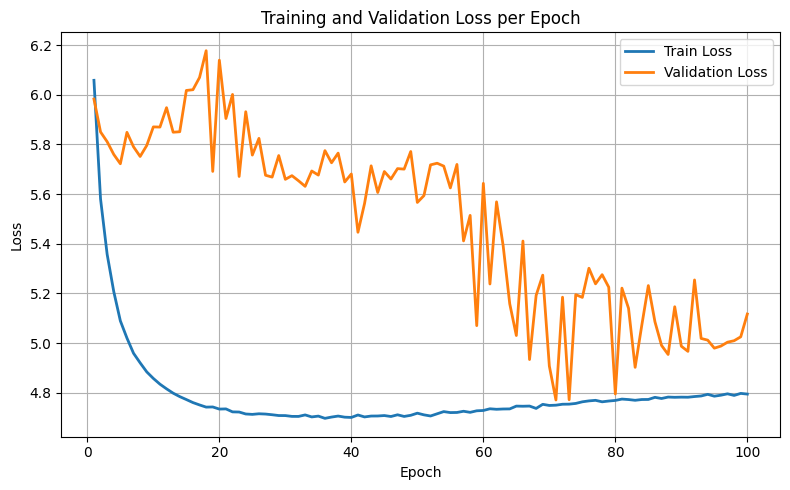

In [1]:
import numpy as np
train_loss_per_epoch = np.load("outputs/train_loss_0-100.npy")
val_loss_per_epoch = np.load("outputs/val_loss_0-100.npy")
import matplotlib.pyplot as plt

epochs = range(1, len(train_loss_per_epoch) + 1)

plt.figure(figsize=(8, 5))
plt.plot(epochs, train_loss_per_epoch, label='Train Loss', linewidth=2)
plt.plot(epochs, val_loss_per_epoch, label='Validation Loss', linewidth=2)

plt.title("Training and Validation Loss per Epoch")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [ ]:
corpus[:50]

In [33]:
generated = generate(model, "well, prince, so Genoa and")
generated

torch.Size([1, 5]) torch.Size([1, 2])
torch.Size([1, 6]) torch.Size([1, 2])
torch.Size([1, 7]) torch.Size([1, 2])
torch.Size([1, 8]) torch.Size([1, 2])
torch.Size([1, 9]) torch.Size([1, 2])


'pardon god help me to'

In [11]:
PATH = "outputs/model_epoch50.pth"
# torch.save(model.state_dict(), PATH)

model.load_state_dict(torch.load(PATH))

# Set the model to evaluation mode for inference


<All keys matched successfully>

In [14]:
vocab = list(tokenizer.word_to_idx.keys())  # or tokenizer.idx_to_word.values()
embeddings = model.embedding.weight.data.cpu().numpy()  # shape: (vocab_size, embedding_dim)

In [19]:
import numpy as np

X = embeddings

from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

# Run TSNE (you can tweak perplexity for better local/global structure)
tsne = TSNE(n_components=2, perplexity=40, random_state=42, n_iter=1500, init="pca")
X_2d = tsne.fit_transform(X)
np.save("outputs/2d_war-peace-embs.npy", X_2d)

In [21]:
word_groups = {
    "characters": ["pierre", "natasha", "andrei", "nikolai", "sonya", "rostov", "kutuzov", "napoleon"],
    "emotions": ["love", "fear", "joy", "sadness", "anger", "hope", "shame", "peace"],
    "warfare": ["battle", "army", "soldier", "war", "gun", "enemy", "victory", "retreat"],
    "religion": ["god", "faith", "soul", "sin", "church", "pray", "heaven"],
    "society": ["count", "princess", "duke", "servant", "emperor", "noble", "peasant"],
    "places": ["moscow", "petersburg", "smolensk", "borodino", "russia", "france"],
    "family": ["father", "mother", "brother", "sister", "wife", "husband", "child"],
    "time": ["day", "night", "morning", "evening", "year", "hour", "moment"],
    "philosophy": ["life", "death", "truth", "freedom", "destiny", "power"],
    "objects": ["horse", "letter", "table", "room", "door", "window", "house"]
}

selected_words = [w for group in word_groups.values() for w in group if w in tokenizer.word_to_idx]
selected_idxs = [tokenizer.word_to_idx[w] for w in selected_words]
X_selected = embeddings[selected_idxs]


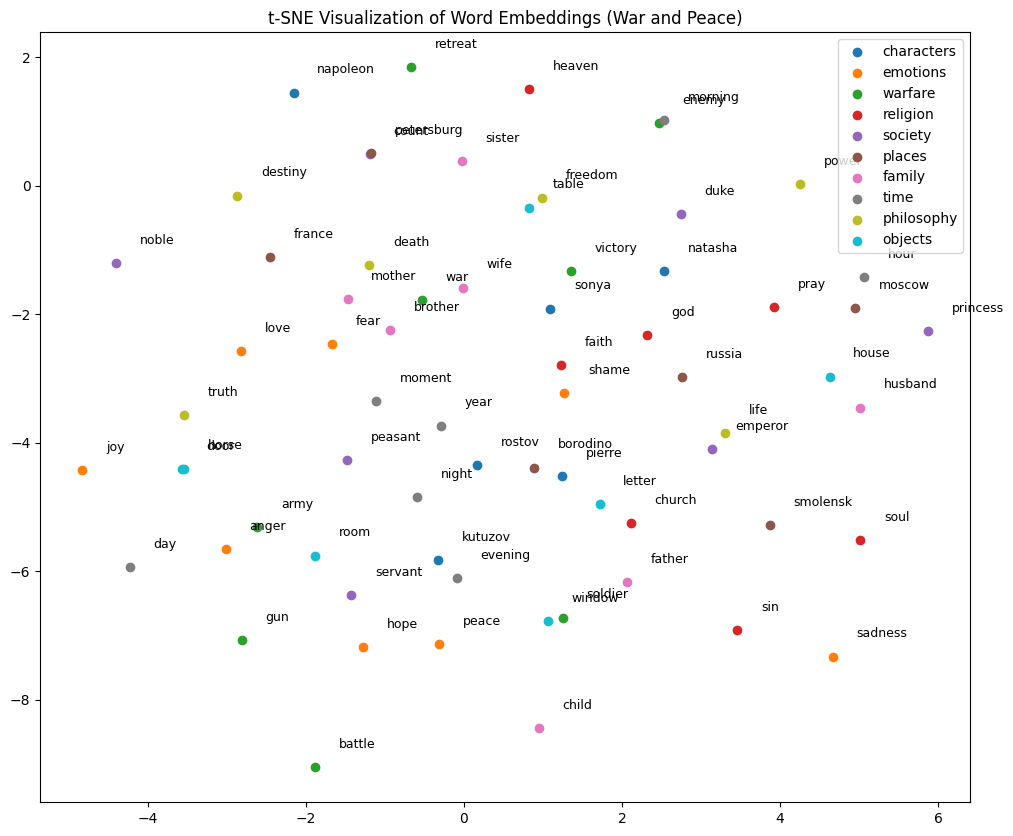

In [22]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

tsne = TSNE(n_components=2, perplexity=20, n_iter=1000, random_state=42)
X_2d = tsne.fit_transform(X_selected)

plt.figure(figsize=(12, 10))
start = 0
for group_name, words in word_groups.items():
    words_in_group = [w for w in words if w in tokenizer.word_to_idx]
    n = len(words_in_group)
    end = start + n
    plt.scatter(X_2d[start:end, 0], X_2d[start:end, 1], label=group_name)
    for i, word in enumerate(words_in_group):
        plt.text(X_2d[start+i, 0]+0.3, X_2d[start+i, 1]+0.3, word, fontsize=9)
    start = end

plt.legend()
plt.title("t-SNE Visualization of Word Embeddings (War and Peace)")
plt.show()


In [23]:
from sklearn.manifold import TSNE

tsne = TSNE(n_components=2, perplexity=30, n_iter=1500, random_state=42, init='pca')
X_all_2d = tsne.fit_transform(embeddings)

selected_words = [w for group in word_groups.values() for w in group if w in tokenizer.word_to_idx]
selected_idxs = [tokenizer.word_to_idx[w] for w in selected_words]

X_selected_2d = X_all_2d[selected_idxs]


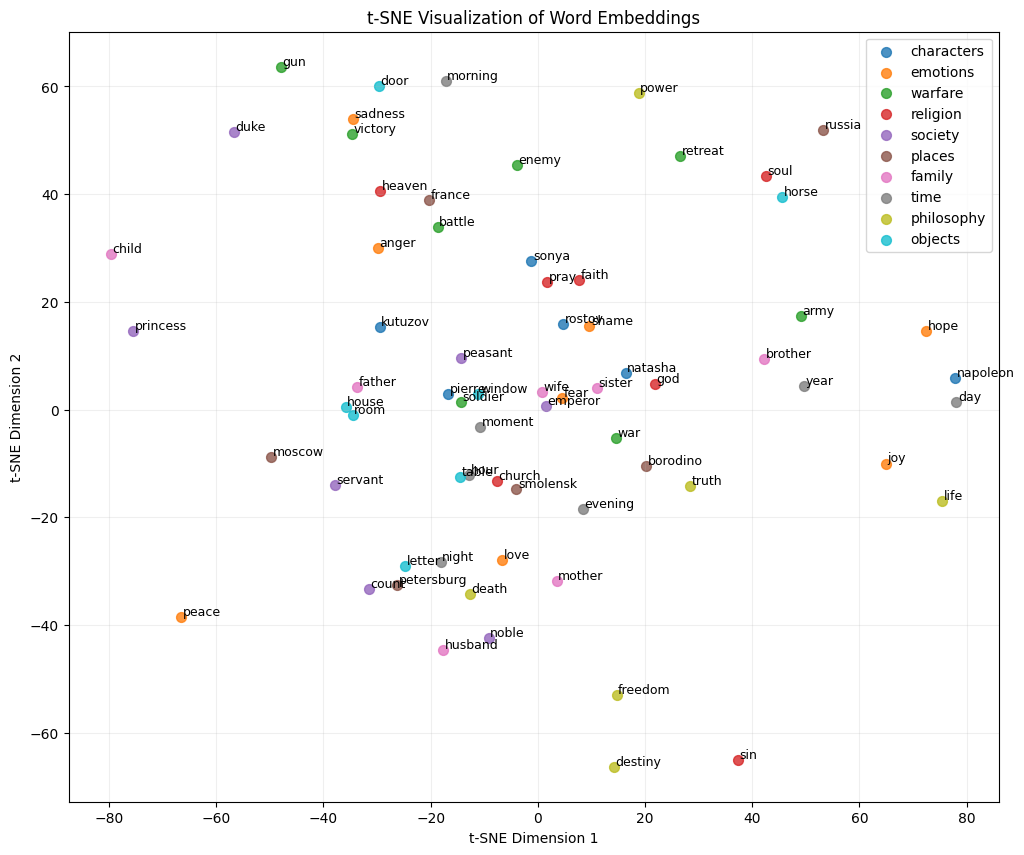

In [24]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 10))
start = 0

for group_name, words in word_groups.items():
    words_in_group = [w for w in words if w in tokenizer.word_to_idx]
    n = len(words_in_group)
    end = start + n

    plt.scatter(
        X_selected_2d[start:end, 0],
        X_selected_2d[start:end, 1],
        label=group_name,
        alpha=0.8,
        s=50
    )

    for i, word in enumerate(words_in_group):
        plt.text(
            X_selected_2d[start + i, 0] + 0.3,
            X_selected_2d[start + i, 1] + 0.3,
            word,
            fontsize=9
        )

    start = end

plt.legend()
plt.title("t-SNE Visualization of Word Embeddings")
plt.xlabel("t-SNE Dimension 1")
plt.ylabel("t-SNE Dimension 2")
plt.grid(True, alpha=0.2)
plt.show()
